## <strong> 11. 시계열 전용 연산

필요한 라이브러리: ```yfinance```, ```pandas_datareader```

In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 6.1 MB/s eta 0:00:01
   ------------ --------------------------- 0.5/1.7 MB 6.1 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.7 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.3 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   ----------------------

In [2]:
import yfinance as yf
import pandas as pd
from matplotlib import pyplot as plt

In [15]:
# 구글 주식 데이터 로딩
goog = yf.download("TSLL", start="2004-01-01", end="2024-12-31")
goog.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLL,TSLL,TSLL,TSLL,TSLL
Date,,,,,
2022-08-09,20.694784,21.638185,20.300272,21.638185,144000
2022-08-10,21.826864,22.212800,20.711935,22.187072,472800
2022-08-11,21.029266,22.264263,20.892045,22.084160,576000
2022-08-12,22.410055,22.444361,20.806275,21.277975,490200
2022-08-15,23.456379,23.910926,22.598742,22.684506,1058100


In [16]:
# [+] 종가(Close) 데이터만 사용하기
goog = shifted = goog. shift (periods= 1)
goog

Price,Close,High,Low,Open,Volume
Ticker,TSLL,TSLL,TSLL,TSLL,TSLL
Date,,,,,
2022-08-09,NaN,NaN,NaN,NaN,NaN
2022-08-10,20.694784,21.638185,20.300272,21.638185,144000.0
2022-08-11,21.826864,22.212800,20.711935,22.187072,472800.0
2022-08-12,21.029266,22.264263,20.892045,22.084160,576000.0
2022-08-15,22.410055,22.444361,20.806275,21.277975,490200.0
...,...,...,...,...,...
2024-12-23,28.554094,32.245141,28.104424,29.209865,106976500.0
2024-12-24,29.975214,30.398725,27.801188,29.937568,55161500.0


<Axes: xlabel='Date'>

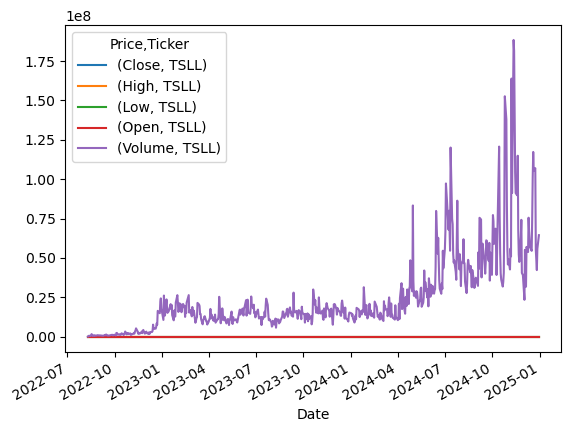

In [17]:
# [+] Lineplot 시각화
goog.plot()

#### <strong> 리샘플링(Resampling)
+ ```resample()```: 빈도를 기준으로 집계 연산
+ ```asfreq()```: 빈도 단위 별 데이터 선택

In [18]:
# [+] 다운샘플링: resample()
goog_downsampled = goog.resample('ME').mean()
goog_downsampled

Price,Close,High,Low,Open,Volume
Ticker,TSLL,TSLL,TSLL,TSLL,TSLL
Date,,,,,
2022-08-31,21.821506,22.462483,21.286233,22.057893,7.676812e+05
2022-09-30,21.059760,21.590140,20.419341,20.976536,9.035429e+05
2022-10-31,14.260608,14.848456,13.678726,14.305557,1.743105e+06
2022-11-30,11.074967,11.612023,10.739199,11.318507,2.540471e+06
2022-12-31,7.994267,8.434289,7.737363,8.177754,7.836562e+06
2023-01-31,5.924684,6.134858,5.567195,5.822303,1.761314e+07
2023-02-28,10.633417,10.973359,10.088190,10.457523,1.800204e+07
2023-03-31,9.720368,10.041121,9.418706,9.766400,1.261301e+07


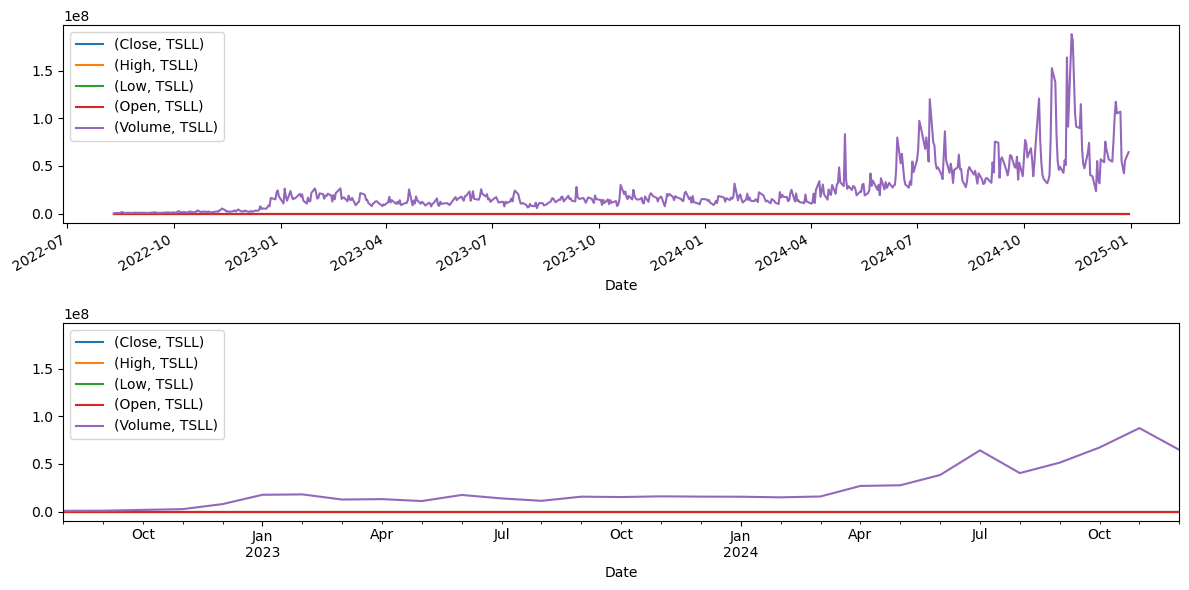

In [19]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))
goog.plot(label='original', ax=ax[0])
ax[0].legend()
goog_downsampled.plot(label='downsampled', ax=ax[1])
ax[1].legend()
plt.tight_layout()

Price           Close       High        Low       Open      Volume
Ticker           TSLL       TSLL       TSLL       TSLL        TSLL
Date                                                              
2022-08-31  19.914335  21.046418  19.356871  21.012111    828400.0
2022-09-30  18.689695  20.311528  18.406518  20.225716   1247000.0
2022-10-31  14.381969  14.407713  13.240680  14.073048   2102000.0
2022-11-30   9.936945  10.387454   9.765323  10.271609   2229000.0
2022-12-31        NaN        NaN        NaN        NaN         NaN
2023-01-31   8.268413   9.272743   8.242439   9.142873  21789600.0
2023-02-28  11.316034  11.458026  10.822527  10.883133  18858400.0
2023-03-31  10.187040  10.334805  10.117504  10.213116   9018000.0
2023-04-30        NaN        NaN        NaN        NaN         NaN
2023-05-31  10.352186  10.604255  10.074042  10.273958  17221700.0
2023-06-30  14.798118  15.068761  14.459376  14.850500  12275800.0
2023-07-31  15.365601  15.417110  14.662799  14.789391   89910

<Axes: xlabel='Date'>

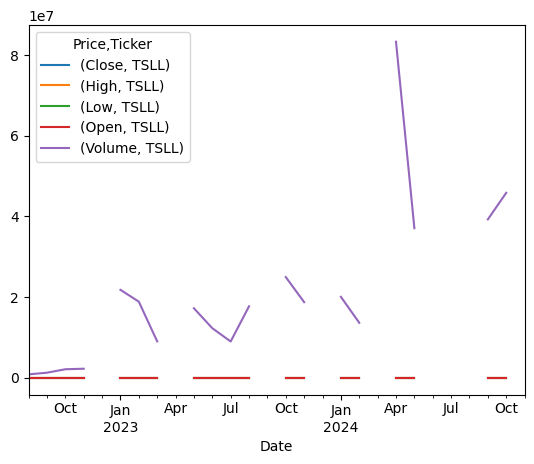

In [20]:
# [+] 다운샘플링: asfreq()
goog_downsampled = goog.asfreq('ME')
print(goog_downsampled)

goog_downsampled.plot()

In [22]:
# [+] 업샘플링: resample()
goog_upsampled = goog.resample('12h').median()
print(goog_upsampled)

Price                    Close       High        Low       Open      Volume
Ticker                    TSLL       TSLL       TSLL       TSLL        TSLL
Date                                                                       
2022-08-09 00:00:00        NaN        NaN        NaN        NaN         NaN
2022-08-09 12:00:00        NaN        NaN        NaN        NaN         NaN
2022-08-10 00:00:00  20.694784  21.638185  20.300272  21.638185    144000.0
2022-08-10 12:00:00        NaN        NaN        NaN        NaN         NaN
2022-08-11 00:00:00  21.826864  22.212800  20.711935  22.187072    472800.0
...                        ...        ...        ...        ...         ...
2024-12-28 00:00:00        NaN        NaN        NaN        NaN         NaN
2024-12-28 12:00:00        NaN        NaN        NaN        NaN         NaN
2024-12-29 00:00:00        NaN        NaN        NaN        NaN         NaN
2024-12-29 12:00:00        NaN        NaN        NaN        NaN         NaN
2024-12-30 0

#### <strong> 시프팅(Shifting)
+ ```shift(periods)``` : ```periods``` 값 만큼 시계열 이동

In [23]:
# [+] 900일 뒤로 시프팅 적용
goog_shifted = goog.shift(periods=900)
goog_shifted

Price,Close,High,Low,Open,Volume
Ticker,TSLL,TSLL,TSLL,TSLL,TSLL
Date,,,,,
2022-08-09,NaN,NaN,NaN,NaN,NaN
2022-08-10,NaN,NaN,NaN,NaN,NaN
2022-08-11,NaN,NaN,NaN,NaN,NaN
2022-08-12,NaN,NaN,NaN,NaN,NaN
2022-08-15,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2024-12-23,NaN,NaN,NaN,NaN,NaN
2024-12-24,NaN,NaN,NaN,NaN,NaN


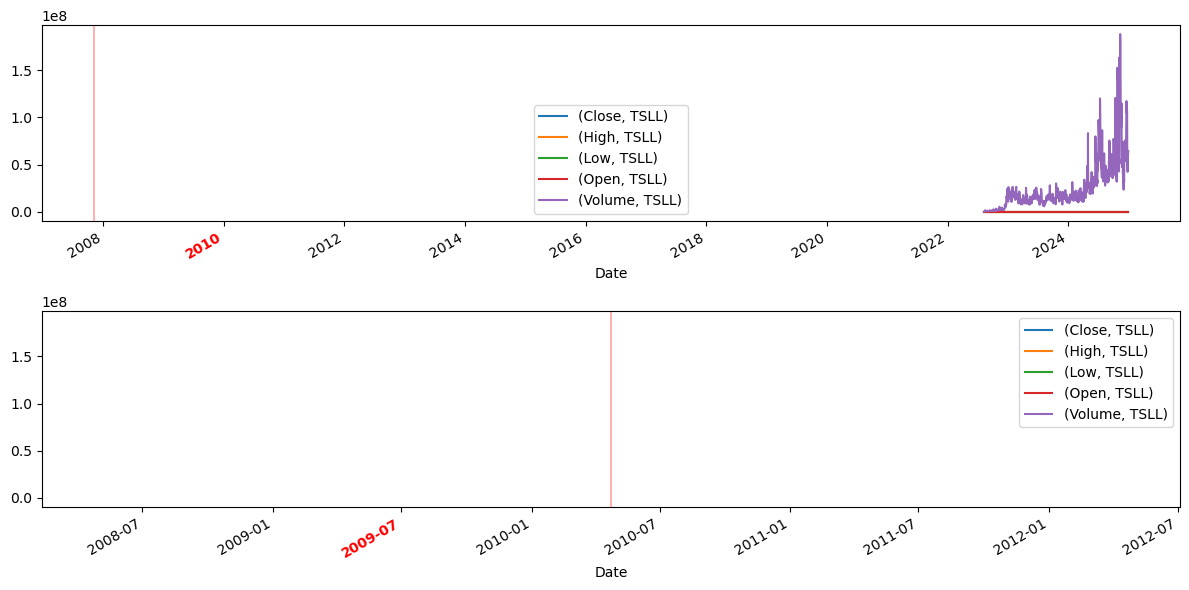

In [24]:
fig, ax = plt.subplots(2, 1, sharey=True, figsize=(12, 6))

# Legends and annotations
local_max = pd.to_datetime('2007-11-05')
offset = pd.Timedelta(900, 'D')

goog.plot(label='original', ax=ax[0])
ax[0].legend()
ax[0].get_xticklabels()[2].set(weight='heavy', color='red')
ax[0].axvline(local_max, alpha=0.3, color='red')

goog_shifted.plot(label='shifted 900 days', ax=ax[1])
ax[1].legend()
ax[1].get_xticklabels()[2].set(weight='heavy', color='red')
ax[1].axvline(local_max + offset, alpha=0.3, color='red')

plt.tight_layout()

In [33]:
# shifting 응용: 주가 변화율 계산
goog_shifted = goog.shift(periods=1) # [+] 시프팅
(goog - goog_shifted) / goog_shifted # [+] 주가 변화율 계산

Price,Close,High,Low,Open,Volume
Ticker,TSLL,TSLL,TSLL,TSLL,TSLL
Date,,,,,
2022-08-09,NaN,NaN,NaN,NaN,NaN
2022-08-10,NaN,NaN,NaN,NaN,NaN
2022-08-11,0.054704,0.026556,0.020279,0.025367,2.283333
2022-08-12,-0.036542,0.002317,0.008696,-0.004638,0.218274
2022-08-15,0.065660,0.008089,-0.004105,-0.036505,-0.148958
...,...,...,...,...,...
2024-12-23,-0.070732,-0.040691,-0.011206,-0.114707,0.016996
2024-12-24,0.049769,-0.057262,-0.010790,0.024913,-0.484359


Price          Close      High       Low      Open      Volume
Ticker          TSLL      TSLL      TSLL      TSLL        TSLL
Date                                                          
2022-08-09       NaN       NaN       NaN       NaN         NaN
2022-08-10       NaN       NaN       NaN       NaN         NaN
2022-08-11  1.132080  0.574615  0.411663  0.548887    328800.0
2022-08-12 -0.797598  0.051463  0.180109 -0.102912    103200.0
2022-08-15  1.380789  0.180099 -0.085770 -0.806185    -85800.0
...              ...       ...       ...       ...         ...
2024-12-23 -2.173405 -1.367747 -0.318513 -3.784726   1787800.0
2024-12-24  1.421120 -1.846416 -0.303236  0.727703 -51815000.0
2024-12-26  4.300989  3.882185  2.691648  0.658790 -12867500.0
2024-12-27 -1.261120  0.409396  2.051679  4.056301  13493700.0
2024-12-30 -3.275156 -2.334017 -3.561262 -2.371664   8652000.0

[602 rows x 5 columns]


<Axes: xlabel='Date'>

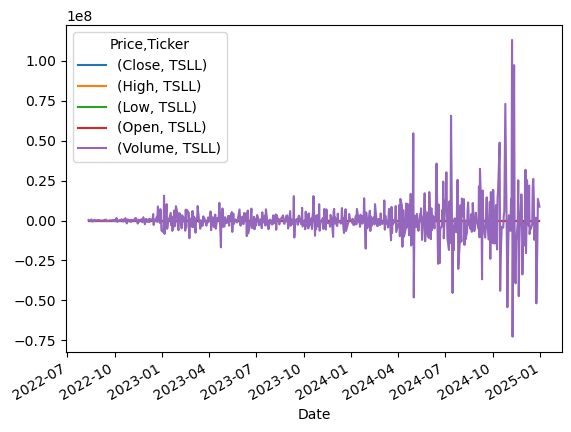

In [34]:
# shifting 응용: 차분 시계열 구하기
goog_diff = goog - goog_shifted  # [+] 차분
print(goog_diff)

goog_diff.plot()

#### <strong> 윈도잉(Windowing)

Rolling [window=365,center=False,axis=0,method=single]


<Axes: xlabel='Date'>

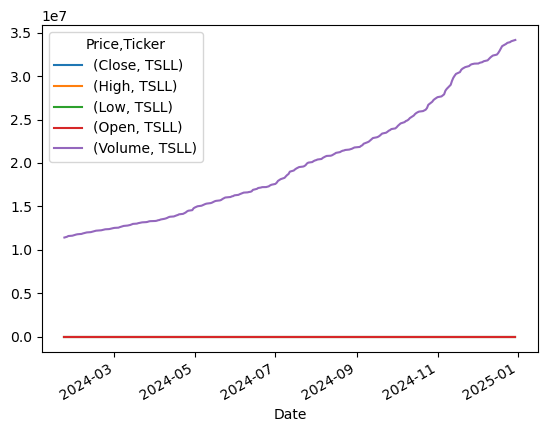

In [36]:
# [+] 365일 단위 윈도잉
goog_rolled = goog.rolling(365)
print(goog_rolled)

goog_rolled.mean().plot()

In [27]:
data = pd.DataFrame({'input': goog.values.flatten(),
                     # moving average
                     'one-year rolling_mean': goog_rolled.mean().values.flatten(), 
                     # standard deviation
                     'one-year rolling_std': goog_rolled.std().values.flatten()}, index=goog.index)
ax = data.plot(style=['-', '--', ':'])
ax.lines[0].set_alpha(0.3)

ValueError: Length of values (3010) does not match length of index (602)